# 🧠Tarea perceptron compuerta AND

### Carga de entradas y definición de hiperparámetros - pesos iniciales

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Datos (AND en {-1,+1})
# =========================
X = np.array([
    [-1, -1,  1],
    [1,  -1,  1],
    [ -1, 1,  1],
    [ 1,  1,  1],
], dtype=float) #entradas
Z = np.array([-1, -1, -1, +1], dtype=float) #salida deseada

# =========================
# Hiperparámetros / Pesos
# =========================
W = np.array([1.0, 1.0, 0.5])   # pesos iniciales [w1, w2, w3] (se pueden probar con otros)
max_epochs = 20  #numnero maximo de epocas

def sgn(x):
    if x > 0: return 1.0
    if x < 0: return -1.0
    return 0.0

def fmt(v):
    return "[" + ", ".join(f"{x:.2f}" for x in np.array(v, dtype=float)) + "]"

print(f"Pesos iniciales: W = {fmt(W)}\n")

Pesos iniciales: W = [1.00, 1.00, 0.50]



### Entrenamiento

Cuando no hay errores en una época, el entrenamiento se detiene automáticamente, porque ya aprendió la función AND correctamente. Por otro lado, cabe la pena recalcar que el número de épocas que se generen depende mucho de los pesos iniciales, los patrones de entrada y en que orden se ingresan.

In [84]:
# =========================
# Entrenamiento con la regla ΔW = Z·X si Z≠Y
# =========================
for epoch in range(1, max_epochs + 1):
    print(f"=== Época {epoch} ===")
    errores = 0

    for i, (x, z) in enumerate(zip(X, Z), start=1):
        W_usados = W.copy()
        S = float(np.dot(W_usados, x))
        Y = sgn(S)

        # nueva regla de aprendizaje:
        if Y != z:
            dW = z * x  # multiplica las entradas por la salida deseada
            errores += 1
        else:
            dW = np.zeros_like(x)

        W_nuevo = W_usados + dW

        print(
            f"Patrón {i}: "
            f"x={x}, Z={int(z)}, "
            f"W(usados)={fmt(W_usados)}, "
            f"S={S: .2f}, Y={int(Y)}, "
            f"{'❌' if Y!=z else '✅'} "
            f"ΔW={fmt(dW)}, W(nuevo)={fmt(W_nuevo)}"
        )

        # actualizar los pesos
        W = W_nuevo

    if errores == 0:
        print("\n✅ Convergió: todos los patrones clasificados correctamente.\n")
        break
    else:
        print(f"Errores en la época: {errores}\n")

W_final = W.copy() #guardamos peso final
print(f"Pesos finales: {fmt(W)}\n")

=== Época 1 ===
Patrón 1: x=[-1. -1.  1.], Z=-1, W(usados)=[1.00, 1.00, 0.50], S=-1.50, Y=-1, ✅ ΔW=[0.00, 0.00, 0.00], W(nuevo)=[1.00, 1.00, 0.50]
Patrón 2: x=[ 1. -1.  1.], Z=-1, W(usados)=[1.00, 1.00, 0.50], S= 0.50, Y=1, ❌ ΔW=[-1.00, 1.00, -1.00], W(nuevo)=[0.00, 2.00, -0.50]
Patrón 3: x=[-1.  1.  1.], Z=-1, W(usados)=[0.00, 2.00, -0.50], S= 1.50, Y=1, ❌ ΔW=[1.00, -1.00, -1.00], W(nuevo)=[1.00, 1.00, -1.50]
Patrón 4: x=[1. 1. 1.], Z=1, W(usados)=[1.00, 1.00, -1.50], S= 0.50, Y=1, ✅ ΔW=[0.00, 0.00, 0.00], W(nuevo)=[1.00, 1.00, -1.50]
Errores en la época: 2

=== Época 2 ===
Patrón 1: x=[-1. -1.  1.], Z=-1, W(usados)=[1.00, 1.00, -1.50], S=-3.50, Y=-1, ✅ ΔW=[0.00, 0.00, 0.00], W(nuevo)=[1.00, 1.00, -1.50]
Patrón 2: x=[ 1. -1.  1.], Z=-1, W(usados)=[1.00, 1.00, -1.50], S=-1.50, Y=-1, ✅ ΔW=[0.00, 0.00, 0.00], W(nuevo)=[1.00, 1.00, -1.50]
Patrón 3: x=[-1.  1.  1.], Z=-1, W(usados)=[1.00, 1.00, -1.50], S=-1.50, Y=-1, ✅ ΔW=[0.00, 0.00, 0.00], W(nuevo)=[1.00, 1.00, -1.50]
Patrón 4: x=[1. 1. 

### Testeo final

In [86]:
# =========================
# 🔍 Prueba final (evaluación del perceptrón entrenado)
# =========================
print("\n")
print("🔍 RESULTADOS DEL TEST FINAL")
print("\n")

aciertos = 0

for i, (x, z) in enumerate(zip(X, Z), start=1):
    S = float(np.dot(W_final, x))  # usamos los pesos finales aprendidos
    Y = sgn(S)
    correcto = (Y == z)
    simbolo = "✅" if correcto else "❌"
    if correcto:
        aciertos += 1

    print(
        f"Patrón {i}: x={x}, "
        f"S={S: .2f}, Y={int(Y)}, Z={int(z)} "
        f"--> {simbolo} {'Correcto' if correcto else 'Incorrecto'}"
    )

# Porcentaje de acierto
precision = aciertos / len(X) * 100
print(f"\n🎯 Precisión final del perceptrón: {precision:.1f}%")
print(f"Pesos finales utilizados: {fmt(W_final)}\n")




🔍 RESULTADOS DEL TEST FINAL


Patrón 1: x=[-1. -1.  1.], S=-3.50, Y=-1, Z=-1 --> ✅ Correcto
Patrón 2: x=[ 1. -1.  1.], S=-1.50, Y=-1, Z=-1 --> ✅ Correcto
Patrón 3: x=[-1.  1.  1.], S=-1.50, Y=-1, Z=-1 --> ✅ Correcto
Patrón 4: x=[1. 1. 1.], S= 0.50, Y=1, Z=1 --> ✅ Correcto

🎯 Precisión final del perceptrón: 100.0%
Pesos finales utilizados: [1.00, 1.00, -1.50]



### Gráfico de frontera de decisión (con pesos finales)

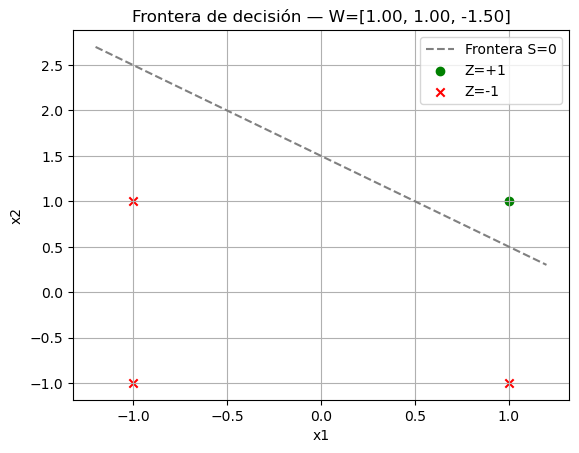

In [89]:
# =========================
# Gráfico de frontera de decisión
# =========================
def plot_decision_boundary(W, X, Z, margin=0.2):
    x1 = X[:, 0]
    x2 = X[:, 1]
    x1_min, x1_max = x1.min() - margin, x1.max() + margin
    xs = np.linspace(x1_min, x1_max, 200)

    plt.figure()
    # frontera: W1*x1 + W2*x2 + W3 = 0  →  x2 = -(W1*x1 + W3)/W2
    if abs(W[1]) < 1e-8:
        plt.axvline(-W[2] / W[0], linestyle='--', color='gray', label='Frontera S=0')
    else:
        ys = ( -W[0] * xs - W[2] ) / W[1]
        plt.plot(xs, ys, linestyle='--', color='gray', label='Frontera S=0')

    pos = (Z == 1)
    neg = (Z == -1)
    plt.scatter(X[pos, 0], X[pos, 1], color='green', marker='o', label='Z=+1')
    plt.scatter(X[neg, 0], X[neg, 1], color='red', marker='x', label='Z=-1')

    plt.xlabel('x1'); plt.ylabel('x2')
    plt.title(f'Frontera de decisión — W={fmt(W)}')
    plt.legend(); plt.grid(True)
    plt.show()

plot_decision_boundary(W_final, X[:, :2], Z)